# Практика. Визуализация в matplotlib

In [4]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

>#### Задание 1
Прочитайте файл `df_fit`.

In [5]:
df = pd.read_csv('data/df_fit.csv')
df

,user id,age group,gender,subscription,steps per day,sleep hours,calories burned,workout count,workout type,water intake,mood score,progress score,sleep cat
0,490,26-35,male,premium,7953,5.2,3370,11,running,2.4,5.4,72.9,4-7
1,54,26-35,male,premium,8096,9.0,3460,18,yoga,2.4,9.0,93.5,>8.5
2,396,26-35,male,free,8677,7.3,2940,7,gym,2.1,7.7,53.7,7-8.5
3,117,26-35,female,free,11394,7.5,2510,2,gym,2.4,8.8,61.9,7-8.5
4,170,26-35,male,free,4373,6.1,2630,6,running,2.4,6.9,44.2,4-7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,146,18-25,male,premium,7556,6.5,3030,8,gym,1.7,7.2,63.3,4-7
496,303,36-50,male,free,8533,6.7,2520,6,swimming,1.8,7.0,64.2,4-7
497,444,26-35,male,free,8740,9.3,3030,7,running,2.4,7.2,63.5,>8.5
498,110,18-25,female,premium,8308,8.7,2830,7,yoga,1.5,7.5,82.3,>8.5


#### Контекст

Стартап «ЗОЖ-метрика» выпустил мобильное приложение для отслеживания физической активности. Приложение собирает данные о пользователях: сколько они ходят, спят, едят, как часто занимаются спортом. Через месяц после запуска команда решила понять, какие факторы влияют на прогресс пользователей и насколько эффективны разные типы подписок (бесплатная vs премиум).

#### Признаки датасета

- user id — ID пользователя (int),
- age group — возрастная группа: '18-25', '26-35', '36-50', '50+' (str),
- gender — 'male' / 'female' (str),
- subscription — тип подписки: 'free' / 'premium' (str),
- steps per day — среднее количество шагов в день (float),
- sleep hours — средняя продолжительность сна в часах (float)
- calories burned — среднее количество сожжённых калорий в день (float),
- workout count — количество тренировок за месяц (int),
- workout type — основной тип тренировки: 'running', 'yoga', 'gym', 'swimming' (str),
- water intake — среднее потребление воды в деньв литрах (float),
- mood score — средняя оценка настроения за месяц в баллах от 0 до 10 (float),
- progress score — итоговый показатель прогресса (0–100), вычисленный приложением на основе всех метрик (целевая переменная) (float).

>#### Задание 2
>- Нарисуйте гистограмму распределения числа пройденных за день шагов (признак `'steps per day'`) с указанием заголовка и подписей по осям. Вклчите сетку. Установите шаг сетки по горизонтали равным 1000 и изменить единицу измерения на 1000 шагов.

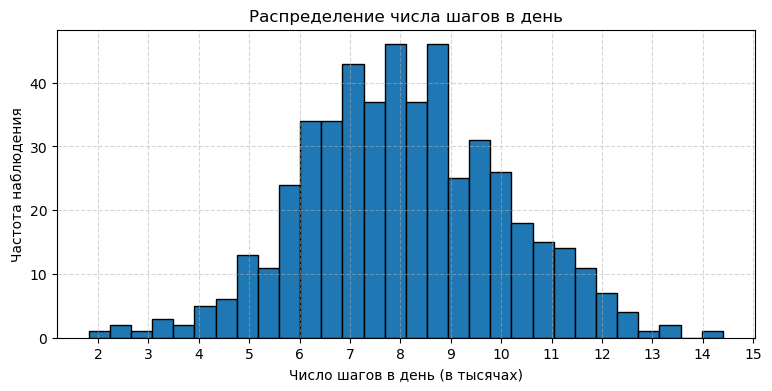

In [23]:
fig, ax = plt.subplots(figsize=(9,4))

step = 1000
positions = range(20000)[::step]
labels = [round(i/step) for i in positions]

ax.set_xticks(positions)
ax.set_xticklabels(labels)

ax.grid(linestyle='--', alpha=0.5)

ax.hist(df['steps per day'], bins = 30, edgecolor='black')

ax.set_title('Распределение числа шагов в день')
ax.set_xlabel('Число шагов в день (в тысячах)')
ax.set_ylabel('Частота наблюдения')

plt.show()

>#### Задание 3
Нарисуйте столбчатую диаграмму (`bar`) для среднего расхода калорий  `calories burned` в зависимости от типа тренировки `workout type`.

In [29]:
instruction = {'calories burned': 'mean'}
grouped = df.groupby('workout type').agg(instruction)
grouped

,calories burned
workout type,
gym,2810.457516
running,2836.114286
swimming,2762.465753
yoga,2835.555556


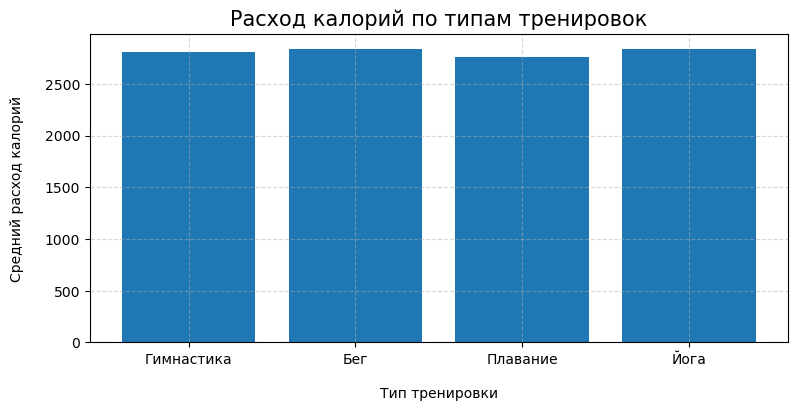

In [41]:
fig, ax = plt.subplots(figsize=(9,4))

ax.grid(linestyle='--', alpha=0.5)

types = ['Гимнастика', 'Бег', 'Плавание', 'Йога']

ax.bar(types, grouped['calories burned'])

ax.set_title('Расход калорий по типам тренировок', fontsize=15)
ax.set_xlabel('Тип тренировки', labelpad=15)
ax.set_ylabel('Средний расход калорий', labelpad=15)

plt.show()

>#### Задание 4
Нарисуйте график зависимости настроения `mood score` от количества выпитой воды `water intake`.

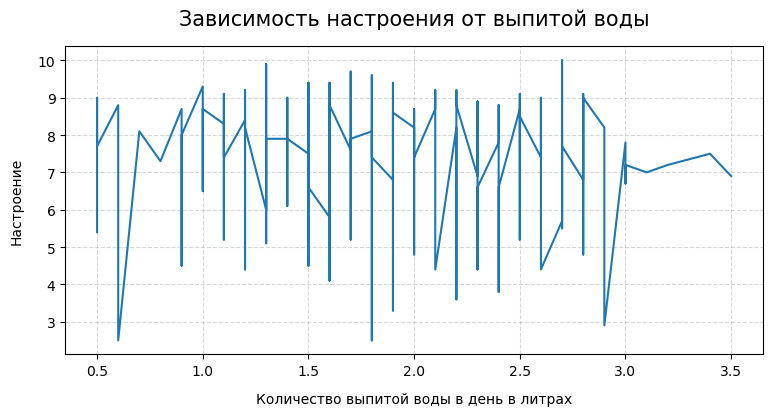

In [50]:
fig, ax = plt.subplots(figsize=(9,4))

ax.grid(linestyle='--', alpha=0.5)

ax.plot(df['water intake'].sort_values(), df['mood score'])

ax.set_title('Зависимость настроения от выпитой воды', fontsize=15, pad=15)
ax.set_xlabel('Количество выпитой воды в день в литрах', labelpad=10)
ax.set_ylabel('Настроение', labelpad=10)

plt.show()

>#### Задание 5
Нарисуйте диаграмму рассеяния (`scatter`) для пары `steps per day`, `calories burned`.

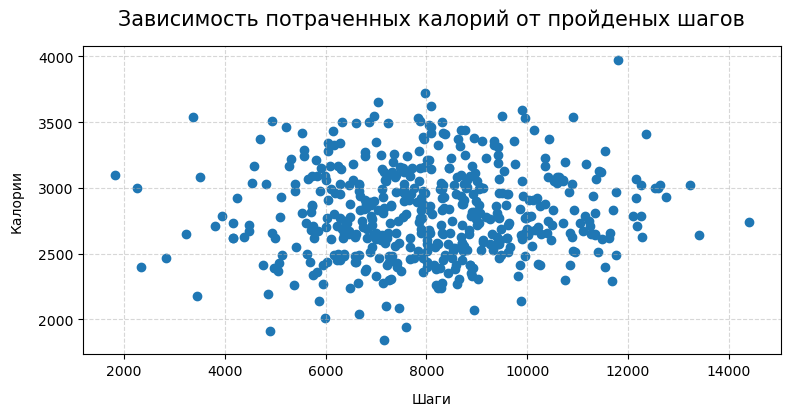

In [54]:
fig, ax = plt.subplots(figsize=(9,4))

ax.grid(linestyle='--', alpha=0.5)

ax.scatter(df['steps per day'], df['calories burned'])

ax.set_title('Зависимость потраченных калорий от пройденых шагов', fontsize=15, pad=15)
ax.set_xlabel('Шаги', labelpad=10)
ax.set_ylabel('Калории', labelpad=10)

plt.show()

>#### Задание 6
Проверьте гипотезу о том, что премиум-подписка приводит к большему прогрессу. Визуализируйте результат проверки при помощи двух ящиков с усами.

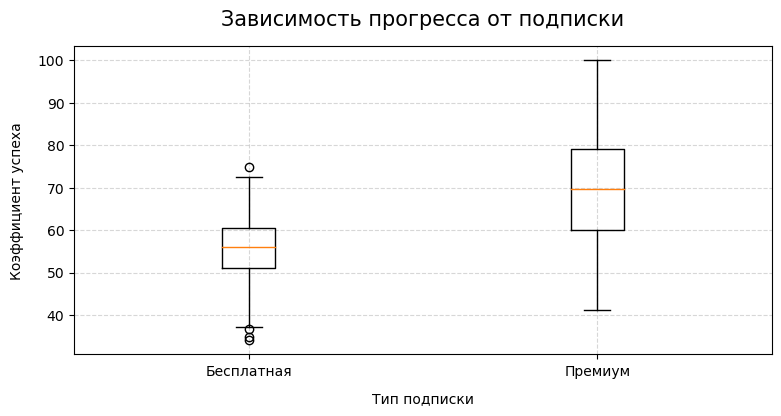

In [67]:
free = df.loc[df['subscription'] == 'free']['progress score']
premium = df.loc[df['subscription'] == 'premium']['progress score']

fig, ax = plt.subplots(figsize=(9,4))

ax.grid(linestyle='--', alpha=0.5)

ax.boxplot([free, premium], labels = ['Бесплатная', 'Премиум'])

ax.set_title('Зависимость прогресса от подписки', fontsize=15, pad=15)
ax.set_xlabel('Тип подписки', labelpad=10)
ax.set_ylabel('Коэффициент успеха', labelpad=10)

plt.show()

>#### Задание 7
Надите ответы на следующие вопросы.
>- Кто активнее на тренировках — мужчины или женщины?
>- Или они активны по разному (у женщин больше шагов, а умужчин — больше тренировок)?
>
>Визуализируйте результат при помощи двух столбчатых диаграмм, реализованных в двух координатных системах одного холста (первая с информацией о шагах, вторая — о числе тренировок).

In [66]:
instruction = {'steps per day': 'mean', 'workout count': 'mean'}
grouped = df.groupby('gender').agg(instruction)
grouped

,steps per day,workout count
gender,,
female,8660.318008,7.666667
male,7445.497908,9.506276


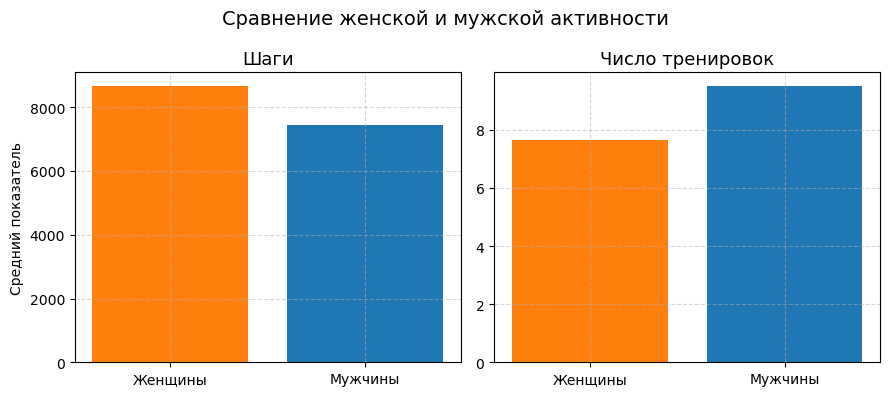

In [87]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9,4))

ax[0].grid(linestyle='--', alpha=0.5)
ax[1].grid(linestyle='--', alpha=0.5)

types = ['Женщины', 'Мужчины']

ax[0].bar(types, grouped['steps per day'], color = ['C1', 'C0'])
ax[1].bar(types, grouped['workout count'], color = ['C1', 'C0'])

ax[0].set_title('Шаги', fontsize=13)
ax[1].set_title('Число тренировок', fontsize=13)
ax[0].set_ylabel('Средний показатель')

fig.suptitle('Сравнение женской и мужской активности', fontsize=14, fontweight='light')

plt.tight_layout()
plt.show()

>#### Задание 8
Правда ли, что те, кто спит 7–8 часов, чувствуют себя лучше остальных? Проанализируйте эту гипотезу и визуализируйте результат.

In [88]:
instruction = {'mood score': 'mean'}
grouped = df.groupby('sleep hours').agg(instruction)
grouped

,mood score
sleep hours,
3.7,3.30
4.1,2.50
4.3,2.70
4.4,4.15
4.6,5.00
...,...
10.1,8.40
10.3,7.20
10.4,7.60


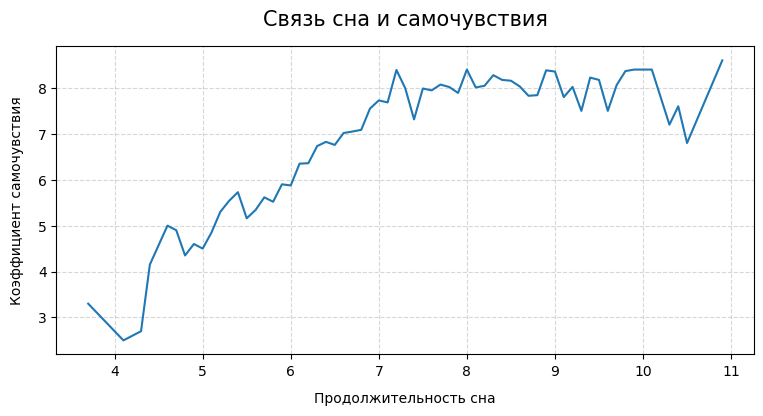

In [99]:
free = df.loc[df['subscription'] == 'free']['progress score']
premium = df.loc[df['subscription'] == 'premium']['progress score']

fig, ax = plt.subplots(figsize=(9,4))

ax.grid(linestyle='--', alpha=0.5)

ax.plot(grouped)

ax.set_title('Связь сна и самочувствия', fontsize=15, pad=15)
ax.set_xlabel('Продолжительность сна', labelpad=10)
ax.set_ylabel('Коэффициент самочувствия', labelpad=10)

plt.show()

## Домашнее задание

>#### Задание 1
Прочитайте файл `df_cafe`.

In [100]:
df = pd.read_csv('data/df_cafe.csv')
df

,customer id,city,card type,visit frequency,avg check,monthly spend,preferred drink,dessert frequency,morning visits,bonus balance,bonus usage rate,churn risk
0,383,SPb,platinum,6.062881,398.151214,9655.773489,tea,0.000000,0.644312,16.769584,0.374683,0.321740
1,415,SPb,silver,3.253165,365.803307,4760.074404,espresso,0.000000,0.629675,280.529634,0.318445,0.126104
2,31,SPb,basic,2.343489,429.903364,4029.895715,latte,0.593516,0.801147,425.469436,0.792604,0.072089
3,735,SPb,basic,3.276985,378.670050,4963.584441,tea,0.967483,0.152480,271.137025,0.680505,0.208035
4,219,SPb,silver,3.858451,365.703776,5644.200571,tea,1.208911,0.454047,259.802003,0.655361,0.379742
...,...,...,...,...,...,...,...,...,...,...,...,...
995,44,Novosibirsk,silver,2.349976,344.703408,3240.179031,latte,0.205989,0.656953,592.310448,0.553342,0.164504
996,280,Kazan,silver,2.520507,305.707148,3082.148065,latte,0.665514,0.178756,1074.061494,0.712824,0.090867
997,491,SPb,basic,3.854749,263.140611,4057.364441,latte,0.028382,0.307392,302.286894,0.762414,0.687675
998,789,SPb,basic,4.068166,353.478221,5752.032719,tea,0.130564,0.416149,11.621574,0.776460,0.672072


####  Контекст
Сеть кофеен «Капучино и точка» запустила новую программу лояльности. Клиенты получают карту, на которой накапливаются баллы. Баллы можно тратить на напитки и десерты. Через три месяца после запуска аналитики решили проверить, как программа повлияла на поведение клиентов и какие факторы определяют лояльность.

#### Признаки датасета

- customer id	— ID клиента (int),
- city — город: 'Moscow', 'SPb', 'Kazan', 'Novosibirsk' (str),
- card type — тип карты: 'basic', 'silver', 'gold', 'platinum' (str),
- visit frequency	— средняя частота посещений в неделю (float),
- avg check — средний чек в рублях (float),
- monthly spend — среднемесячные траты в рблях (float),
- preferred drink	— любимый напиток: 'latte', 'cappuccino', 'espresso', 'mocha', 'tea'(str),
- dessert frequency — как часто покупает десерт в неделю (float),
- morning visits — доля утренних визитов (с 7:00 до 11:00) (float),
- bonus balance — текущий баланс баллов (float),
- bonus usage rate доля баллов, потраченных от общего накопленного объёма (float),
- churn risk — риск оттока (0–1), предсказанный моделью (float)/

>#### Задание 2
Нарисуйте гистограмму распределения среднего чека с подписями и сеткой.

In [ ]:
# Код

>#### Задание 3
Нарисуйте столбчатую диаграмму среднего средней частоты посещений по городам.

In [ ]:
# Код

>#### Задание 4
Нарисуйте совместное распределение среднего чека и частотой визитов.

In [101]:
# Код

>#### Задание 5
Сруппируйте данные по типу карты и нарисуйте график зависомости текущего баланса баллов от частоты визитов.

In [ ]:
# Код

>#### Задание 6
Нарисуйте столбчатые гистораммы того, как распределены либимые напритки по типам карт.

In [102]:
# Код

>#### Задание 7
Проверьте гипотезу, что «платиновые» клиенты тратят больше и приходят чаще. Визуализируйте результат.

In [103]:
# Код

>#### Задание 8
Есть ли региональные предпочтения? Например, в Москве любят капучино, а в Питере — латте?

In [104]:
# Код

>#### Задание 8
Вотрос: те, кто активно тратит баллы, — более лояльны? Или наоборот: кто тратит баллы, тот уже одной ногой у конкурентов?